In [1]:
%load_ext autoreload
%autoreload 2

****************************************
# Galactic: Crab Analysis (DC1 and DC2)

This notebook analyzes the Crab source using both the **DC1-style Crab simulation** and the newer **DC2 Crab simulation**.

The purpose is to compare the two analysis cases within the DC2 framework while reusing a familiar source.

For **Crab DC1**, the goals are to:

- Localize the source
- Measure the spectrum
- Reconstruct an image of the source

For **Crab DC2**, the goal is to:

- Detect the source
- Measure the phase-integrated spectrum

The DC2 Crab simulation includes the combined **pulsar + nebula spectrum**, divided into five energy bands from **100 keV to 10 MeV**. 
**************

## set up

### imports

In [2]:
import numpy as np
import pandas as pd 
import cosipy as cp 

from pathlib import Path
import sys

repo_root = Path.cwd().parent

import astropy.units as u
import matplotlib.pyplot as plt

from threeML import Band, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw

from astropy.io import fits

%matplotlib inline

### data

Define file names

In [74]:
data_dir = Path(repo_root, "data")

data_crab_dc1 = data_dir / "data-products/downloads/crab_3months_unbinned_data.fits.gz"
data_crab_dc2 = data_dir / "data-products/downloads/Crab_DC2_3months_unbinned_data.fits.gz"
data_orientation = data_dir / "data-products" / "downloads" / "20280301_3_month_with_orbital_info.fits"


data_response = data_dir / (
    "data-products/downloads/"
    "SMEXv12.Continuum.HEALPixO3_10bins_log_flat."
    "binnedimaging.imagingresponse.h5"
)

data_background = data_dir / "backgrounds/downloads/total_bg_3months_unbinned_data.fits.gz"

In [4]:
# Paths to the binned data files
crab_dc1_binned = repo_root / "data" / "data-products" / "binned" / "crab_binned_data_dc1.hdf5"
crab_dc2_binned = repo_root / "data" / "data-products" / "binned" / "crab_binned_data_dc2.hdf5"
background_binned = repo_root / "data" / "backgrounds" / "binned" / "background_binned_data.hdf5"

In [5]:

# Checking the contents of the FITS file for YAML file creation
with fits.open(data_crab_dc1) as hdul:
    hdul.info()
    print(hdul[1].columns.names)
    # Checking the time range of the data
    times = hdul[1].data["TimeTags"]
# Obtaining the minimum and maximum time values from the TimeTags column
print('tmin:', times.min(), 'tmax:', times.max())

Filename: /Users/maura/Documents/COSI/data-challenge-2/data/data-products/downloads/crab_3months_unbinned_data.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     46   6432442R x 11C   [D, D, 2D, 2D, 2D, D, D, D, D, D, D]   
['Energies', 'TimeTags', 'Xpointings (glon,glat)', 'Ypointings (glon,glat)', 'Zpointings (glon,glat)', 'Phi', 'Chi local', 'Psi local', 'Distance', 'Chi galactic', 'Psi galactic']
tmin: 1835487684.5801868 tmax: 1843466661.583874


### Inputs

In [6]:
l_crab,b_crab = 184.55746, -5.78436 # Galactic longitude & latitude of Crab

ul = 3 # SNR limit for upper limits on spectral fit

***
## Binning the Data

### DC1, DC2 & background binning

In [7]:
# In this part, it seems that it read the intups.yaml (this is the file that contains the inputs for the analysis.)
# In data-challenge-1 this was done in the notebook, but in data-challenge-2 it is done in the inputs.yaml file. (automated)
analysis1 = cp.BinnedData("inputs.yaml")
analysis2 = cp.BinnedData("inputs.yaml")
analysisbg = cp.BinnedData("inputs.yaml")



In [ ]:
# Create the bins if the binned data files do not exist yet

if not crab_dc1_binned.exists():
    analysis1.get_binned_data(
        unbinned_data=str(data_crab_dc1),
        output_name=str(crab_dc1_binned.with_suffix(""))
    )

if not crab_dc2_binned.exists():
    analysis2.get_binned_data(
        unbinned_data=str(data_crab_dc2),
        output_name=str(crab_dc2_binned.with_suffix(""))
    )

if not background_binned.exists():
    analysisbg.get_binned_data(
        unbinned_data=str(data_background),
        output_name=str(background_binned.with_suffix(""))
    )

# Always load the existing/generated files into the objects
analysis1.load_binned_data_from_hdf5(
    binned_data=str(crab_dc1_binned)
)
analysis2.load_binned_data_from_hdf5(
    binned_data=str(crab_dc2_binned)
)
analysisbg.load_binned_data_from_hdf5(
    binned_data=str(background_binned)
)

In [ ]:
# Since we loaded the binned data from the HDF5 files, we can now get the binning information for each analysis object
analysis1.get_binning_info()
analysis2.get_binning_info()
analysisbg.get_binning_info()

In [9]:
# are our data files created?
print("Crab DC1 binned data exists:", crab_dc1_binned.exists())
print("Crab DC2 binned data exists:", crab_dc2_binned.exists()) 
print("Background binned data exists:", background_binned.exists())

Crab DC1 binned data exists: True
Crab DC2 binned data exists: True
Background binned data exists: True


### Exploring raw binned data: File shape & plots

In [10]:
# lets see the shape of the binned data
print("Crab DC1 binned data shape:", analysis1.binned_data.shape)
print("Crab DC2 binned data shape:", analysis2.binned_data.shape)
print("Background binned data shape:", analysisbg.binned_data.shape) 

Crab DC1 binned data shape: (1108, 10, 36, 768)
Crab DC2 binned data shape: (1108, 10, 36, 768)
Background binned data shape: (1108, 10, 36, 768)


In [56]:
# Inspect the bin centers, edges, and widths for time and energy
print("Time centers:", analysis1.time_bin_centers)
print("Time widths:", analysis1.time_bin_widths)

print("Energy centers:", analysis1.energy_bin_centers)
print("Energy edges:", analysis1.energy_bin_edges)
print("Energy widths:", analysis1.energy_bin_widths)

Time centers: [1.83549129e+09 1.83549849e+09 1.83550569e+09 ... 1.84344866e+09
 1.84345586e+09 1.84346306e+09] s
Time widths: [7201.24278307 7201.24278307 7201.24278331 ... 7201.24278331 7201.24278307
 7201.24278307] s
Energy centers: [ 129.2445  204.839   324.648   514.532   815.4785 1292.445  2048.39
 3246.48   5145.32   8154.785 ] keV
Energy edges: [  100.      158.489   251.189   398.107   630.957  1000.     1584.89
  2511.89   3981.07   6309.57  10000.   ] keV
Energy widths: [  58.489   92.7    146.918  232.85   369.043  584.89   927.    1469.18
 2328.5   3690.43 ] keV


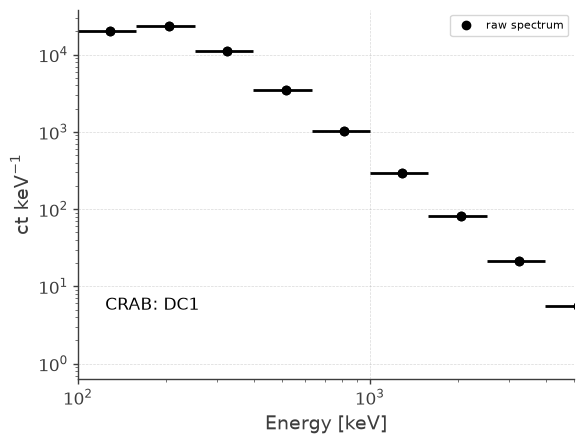

In [59]:
# Plot the raw spectrum for DC1
# We first add text in the plot indicating "Crab: DC1"
fig, ax = plt.subplots()
ax.text(0.15, 0.2, 'CRAB: DC1', transform=ax.transAxes, ha='center', va='center')
analysis1.get_raw_spectrum(show_plots=True
)


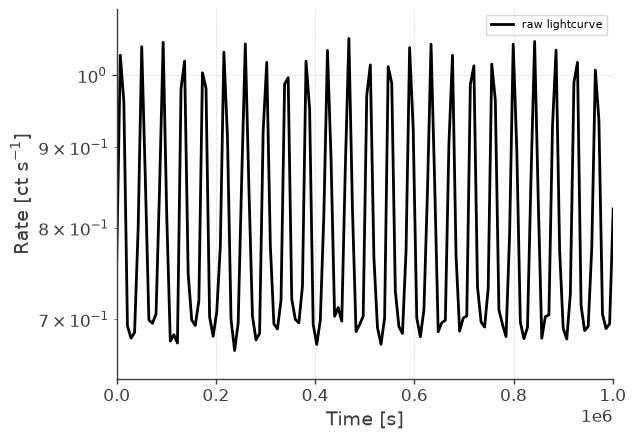

In [61]:
# Plotting DC1 lightcurve
plt.figure()
plt.xlim(0, 1e6)
analysis1.get_raw_lightcurve(show_plots=True)

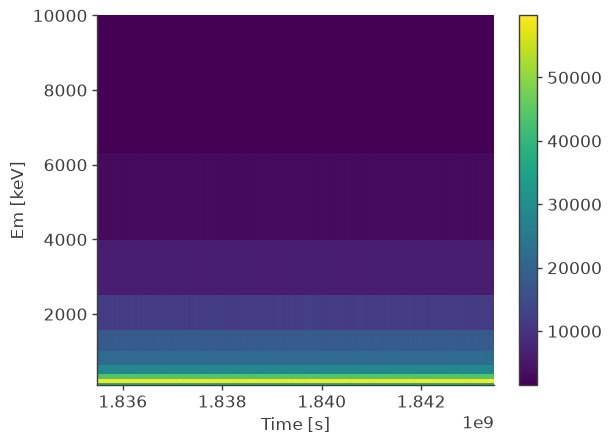

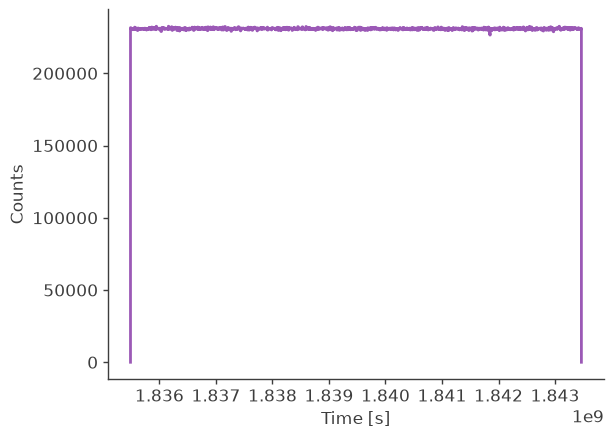

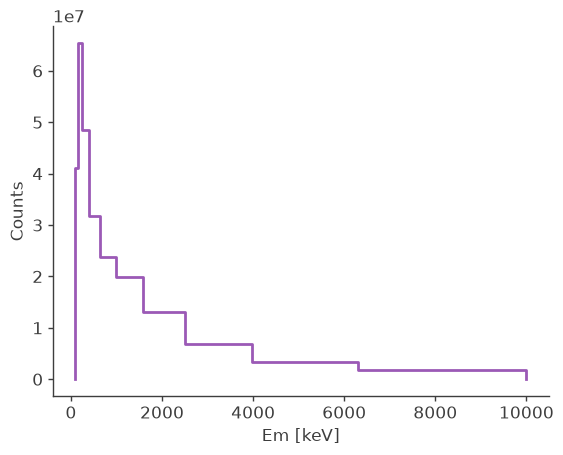

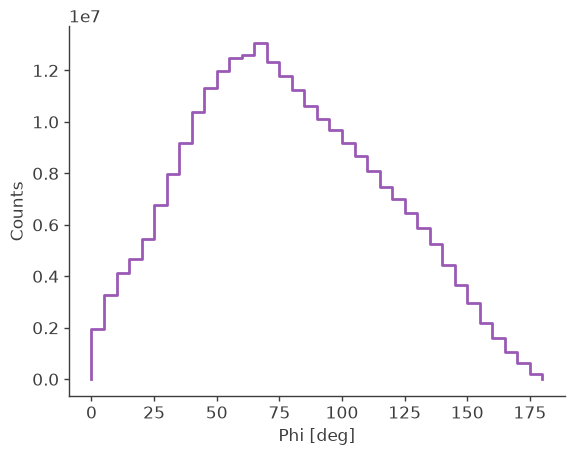

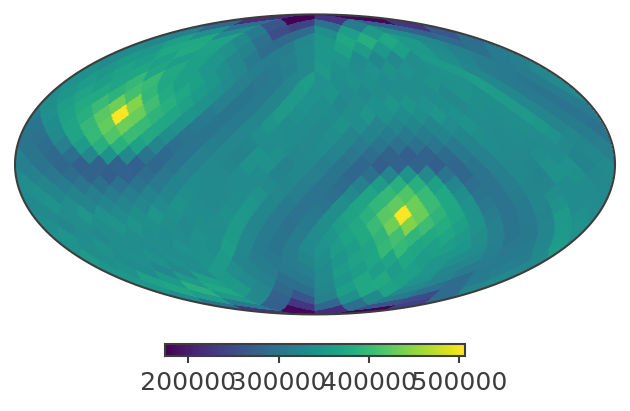

In [55]:
# Plot the binned data projected onto each axis
analysisbg.plot_binned_data(show_plots=True)

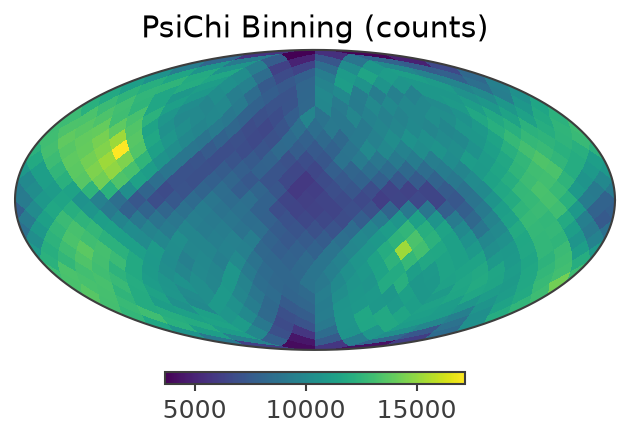

In [57]:
# Plot the event distribution in PsiChi coordinates
analysis2.plot_psichi_map(show_plots=True)

## Detector response & signal expectation

###  Detector response

In [75]:
response = cp.response.FullDetectorResponse.open(data_response)
print("Response object created:", response.filename)
response.close()

Response object created: /Users/maura/Documents/COSI/data-challenge-2/data/data-products/downloads/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5


### Point Source sensitivity

In [66]:
# Load the space craft orientation history
orientation = cp.SpacecraftHistory.open(data_orientation)